In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Height vs Weight')

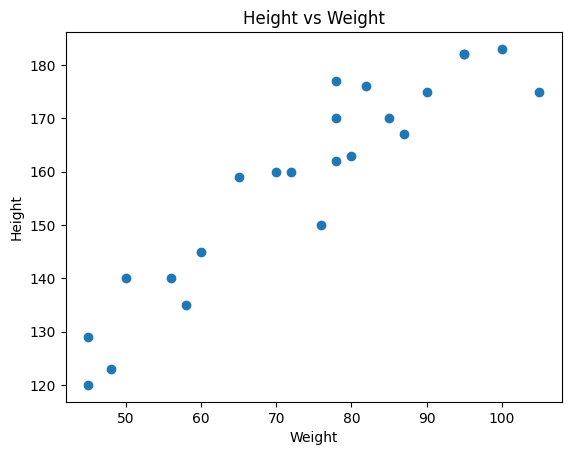

In [4]:
#scatter plot
plt.scatter(df.Weight,df.Height)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Height vs Weight')

In [5]:
#Correlation
correlation = df.corr()
print(correlation)

          Weight    Height
Weight  1.000000  0.931142
Height  0.931142  1.000000


<Axes: >

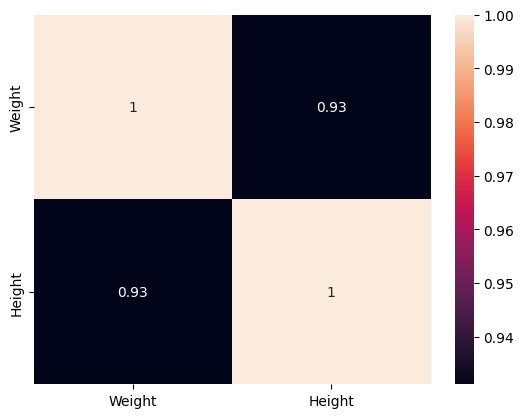

In [6]:
import seaborn as sns
sns.heatmap(correlation, annot=True)

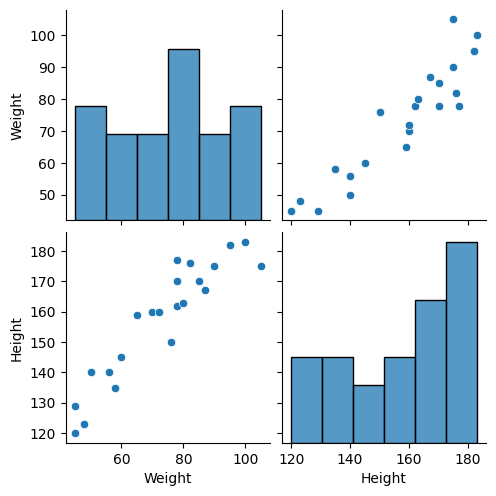

In [7]:
sns.pairplot(df)

In [8]:
# Independednt and Dependent Features
X = df[['Weight']]
y = df['Height']

In [9]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train.shape,X_test.shape

((18, 1), (5, 1))

In [11]:
#Standardizing the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), 
                               columns=X_train.columns,
                               index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test),
                              columns=X_test.columns,
                              index=X_test.index)

In [12]:
X_train

,Weight
12,1.736891
1,-0.920270
13,1.454214
5,0.210437
2,-1.485623
11,1.171538
20,-1.655229
3,-0.807199
4,-0.241846
18,0.097366


In [13]:
#Applying Simple Linear Regression
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
print("Coefficient or slope is:",regressor.coef_[0])
print("Coefficient or intercept is:",regressor.intercept_)

Coefficient or slope is: 17.034408719095538
Coefficient or intercept is: 157.5


In [15]:
predictions = regressor.predict(X_test)

In [16]:
regressor.predict(scaler.transform([[72]]))

c:\Users\Abhis\OneDrive\Desktop\Projects\Intelligent Support System\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Abhis\OneDrive\Desktop\Projects\Intelligent Support System\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([155.30639545])

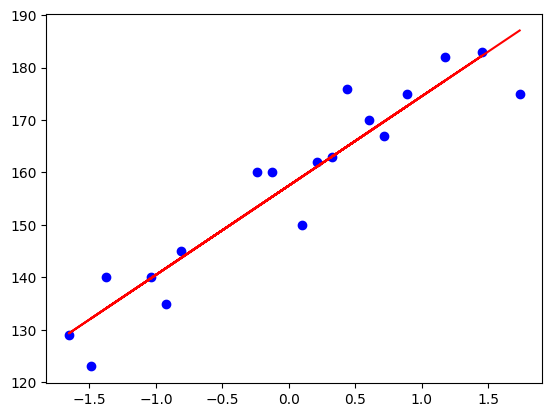

In [17]:
# Plot Training Best Fit Line
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, regressor.predict(X_train), color='red')

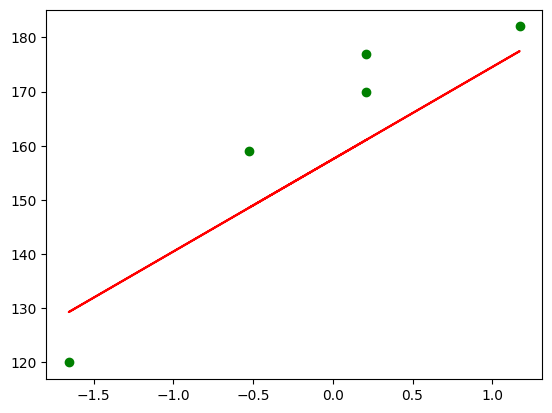

In [18]:
# Prediction for test data
plt.scatter(X_test, y_test, color='green')
plt.plot(X_test, predictions, color='red')

In [19]:
residuals = y_test - predictions

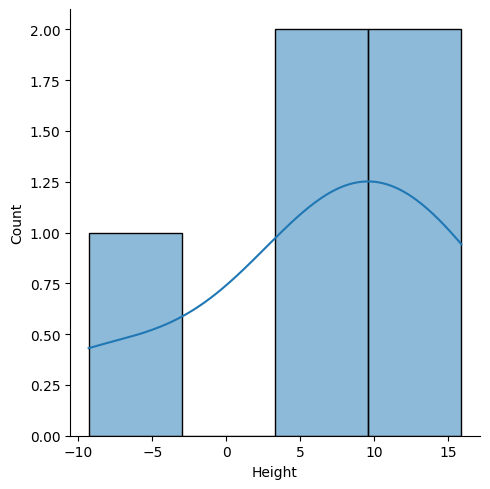

In [20]:
sns.displot(residuals,kde = True)

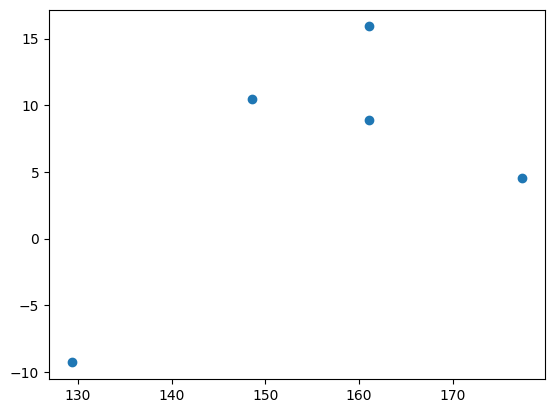

In [21]:
plt.scatter(predictions, residuals)

In [19]:
## Evaluating the Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)   
print("Root Mean Squared Error:", rmse)
print("R^2 Score:", r2)
print("Adjusted R^2 Score:", 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

Mean Absolute Error: 9.822657814519232
Mean Squared Error: 109.77592599051664
Root Mean Squared Error: 10.477400726827081
R^2 Score: 0.776986986042344
Adjusted R^2 Score: 0.7026493147231252


In [20]:
#OLS Regression Summary
import statsmodels.api as sm

In [21]:
X_train_with_const = sm.add_constant(X_train)
X_test_with_const = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train_with_const).fit()

In [22]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Height   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     133.6
Date:                Wed, 31 Dec 2025   Prob (F-statistic):           3.53e-09
Time:                        09:59:45   Log-Likelihood:                -57.473
No. Observations:                  18   AIC:                             118.9
Df Residuals:                      16   BIC:                             120.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        157.5000      1.474    106.879      0.0

c:\Users\Abhis\OneDrive\Desktop\Projects\Intelligent Support System\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [23]:
# Make prediction
weight_scaled = scaler.transform([[72]])[0][0]
prediction = model.predict([1, weight_scaled])  # [1] is for the constant
print(f"Predicted height: {prediction[0]}")

Predicted height: 155.30639544633956


c:\Users\Abhis\OneDrive\Desktop\Projects\Intelligent Support System\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
